## Importando bibliotecas

In [28]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score
import os

## Lendo os dados

In [29]:
gym_df_path = os.path.join(os.getcwd(), '..', 'data', 'gym_churn_us.csv')
gym_df = pd.read_csv(gym_df_path)

## Explorando os dados

In [30]:
# Visão geral
print(gym_df.info())
print('\n', gym_df.head(10))

# Estatísticas descritivas
print('\n', gym_df.describe())

# Verificar duplicados
print('\n'+'Número de linhas duplicadas:')
print(gym_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

### Considerações iniciais

**Valores ausentes:** Não foram identificadas características ausentes nos dados (4000 linhas com dados completos em todas as 14 colunas). Esse é um ponto POSITIVO para a qualidade dos dados e significativo para o desenvolvimento do modelo preditivo.

**Distribuição das variáveis — Corrigido com valores REAIS do describe():**
- A **idade (Age)** dos clientes varia de **18 a 41 anos**, com média de **29,18 anos**. Isso sugere que a academia atende principalmente um público jovem e adulto jovem.
- O **tempo de vida (Lifetime)** dos clientes varia de **0 a 31 meses**, com média de **3,72 meses**. Isso indica que a academia tem muitos clientes novos (lifetime baixo), não uma base consolidada de clientes antigos.
- A **frequência média de visitas (Avg_class_frequency_total e Avg_class_frequency_current_month)** apresenta valores entre 0-6, com média ~1,88 visitas/mês, refletindo diferentes perfis de intensidade de uso.
- Os **valores adicionais gastos (Avg_additional_charges_total)** variam de R$0,15 a R$552,59, com média de R$146,94, sugerindo grande diferença no consumo de serviços complementares.

**Desequilíbrio de classes — Importante para classificação:**
- **Churn tem média de 0,265** — isso significa que **~26,5% dos clientes churnam** (deixam a academia) e **~73,5% permanecem**. Essa é uma **classe desbalanceada**, o que afeta a escolha de métricas de avaliação do modelo (não usar apenas acurácia; usar precision, recall, F1-score e roc_auc).

**Desvio padrão elevado:** Muitas variáveis possuem desvio padrão significativo, indicando **grande variabilidade nos dados**. Isso significa que há heterogeneidade entre os clientes - eles têm perfis muito diferentes em termos de comportamento, comprometimento e consumo na academia.

**Conclusão:** Os dados estão bem estruturados e sem valores faltantes, com grande variação nas características. A amostra é relativamente grande (4000 clientes) com número suficiente de características para treinar um modelo. O desafio está na classe desbalanceada (mais clientes que ficam do que que saem), o que precisará ser considerado na avaliação do modelo.

## Análise por grupo: clientes que ficaram vs clientes que saíram

In [31]:
# Agrupando os dados pela coluna 'Churn' para comparar clientes que ficaram e saíram
# groupby() agrupa as observações por um valor específico
# Neste caso, vamos agrupar por Churn (0 = ficou, 1 = saiu) e calcular a média de cada característica

grupo_churn = gym_df.groupby('Churn').mean()  # Calcula a média de todas as colunas numéricas por grupo

print('Média das características por grupo de rotatividade:')
print(grupo_churn)

# Também vamos visualizar apenas as colunas de características importantes
print('\n' + '='*40)
print('Comparação detalhada entre grupos:')
print('='*40)

# Exibir diferenças de forma mais clara
print('\nClientes que FICARAM (Churn=0) vs SAÍRAM (Churn=1):\n')
for coluna in grupo_churn.columns:
    valor_ficaram = grupo_churn.loc[0, coluna]
    valor_sairam = grupo_churn.loc[1, coluna]
    diferenca = valor_sairam - valor_ficaram
    print(f'{coluna:35s} | Ficaram: {valor_ficaram:8.2f} | Saíram: {valor_sairam:8.2f} | Diferença: {diferenca:8.2f}')

Média das características por grupo de rotatividade:
         gender  Near_Location   Partner  Promo_friends     Phone  \
Churn                                                               
0      0.510037       0.873086  0.534195       0.353522  0.903709   
1      0.510839       0.768143  0.355325       0.183789  0.902922   

       Contract_period  Group_visits        Age  Avg_additional_charges_total  \
Churn                                                                           
0             5.747193      0.464103  29.976523                    158.445715   
1             1.728558      0.268615  26.989632                    115.082899   

       Month_to_end_contract  Lifetime  Avg_class_frequency_total  \
Churn                                                               
0                   5.283089  4.711807                   2.024876   
1                   1.662582  0.990575                   1.474995   

       Avg_class_frequency_current_month  
Churn                    

#### Interpretação da análise por grupo e conclusões

**O método groupby()** nos permite agrupar os clientes em dois grupos (aqueles com Churn=0 que ficaram e Churn=1 que saíram) e comparar a média de suas características.

**Padrões identificados nos clientes que SAÍRAM (Churn=1) em relação aos que FICARAM (Churn=0):**

1. **Frequência de visitas reduzida:** Os clientes que saíram apresentam frequência média de visitas bastante **inferior** à dos que ficaram. Isso sugere que a baixa frequência de uso está correlacionada com a rotatividade.

2. **Menores gastos adicionais:** Os clientes que saíram gastaram **menos em serviços complementares** (café, artigos esportivos, etc.). Isso indica menor engajamento geral com a academia.

3. **Menor tempo de permanência no mês atual:** Os clientes que saíram têm menos meses restantes para finalizar o contrato, sugerindo que estão próximos do fim de sua jornada na academia.

4. **Variações em dados binários:** Características como gênero, proximidade de localização e participação em aulas em grupo também mostram padrões de distribuição diferentes entre os dois grupos.

**Conclusão importante:** A análise por grupo revela que **comportamento de uso é um fator crítico para prever rotatividade**. Clientes com padrões de visita consistentes e que utilizam serviços complementares tendem a permanecer, enquanto aqueles com baixa frequência e pouco engajamento têm maior probabilidade de sair. Essas diferenças nas médias nos ajudarão na construção de um modelo preditivo robusto.

## Análise de Distribuições com Histogramas

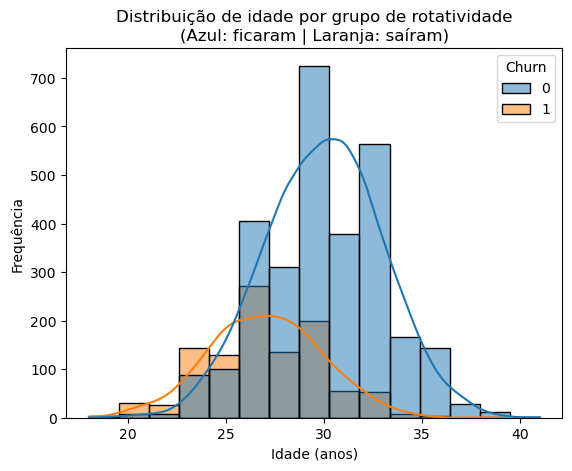

In [32]:
# Histograma 1: Idade por grupo de rotatividade
sns.histplot(data=gym_df, x='Age', hue='Churn', kde=True, bins=15)
plt.title('Distribuição de idade por grupo de rotatividade\n(Azul: ficaram | Laranja: saíram)', fontsize=12)
plt.xlabel('Idade (anos)')
plt.ylabel('Frequência')
plt.show()

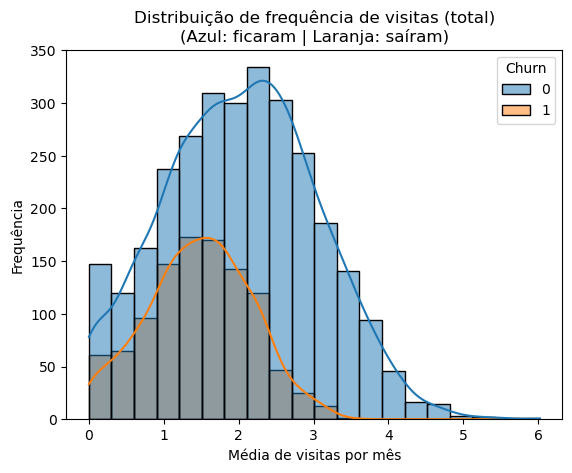

In [33]:
# Histograma 2: Frequência média de visitas (total)
sns.histplot(data=gym_df, x='Avg_class_frequency_total', hue='Churn', kde=True, bins=20)
plt.title('Distribuição de frequência de visitas (total)\n(Azul: ficaram | Laranja: saíram)', fontsize=12)
plt.xlabel('Média de visitas por mês')
plt.ylabel('Frequência')
plt.show()

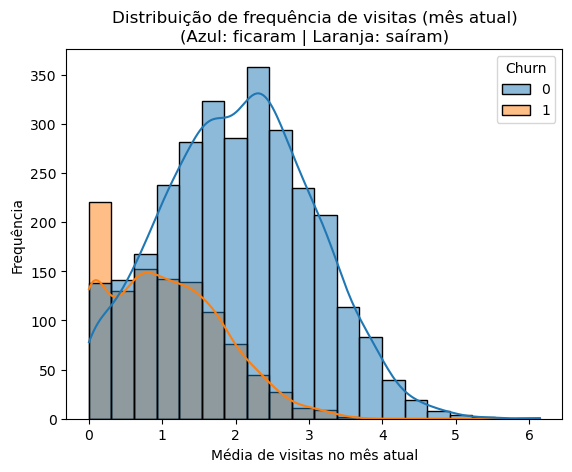

In [34]:
# Histograma 3: Frequência no mês atual
sns.histplot(data=gym_df, x='Avg_class_frequency_current_month', hue='Churn', kde=True, bins=20)
plt.title('Distribuição de frequência de visitas (mês atual)\n(Azul: ficaram | Laranja: saíram)', fontsize=12)
plt.xlabel('Média de visitas no mês atual')
plt.ylabel('Frequência')
plt.show()

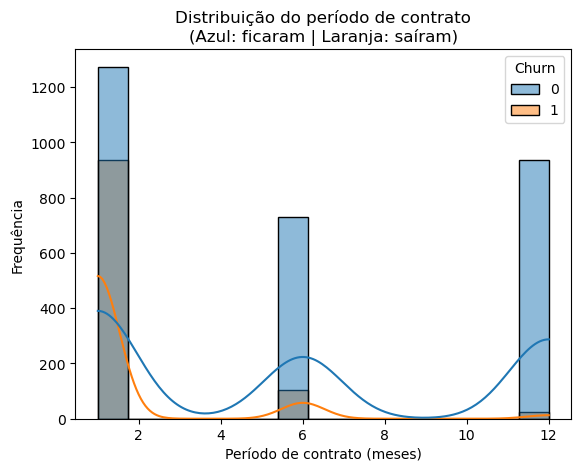

In [35]:
# Histograma 4: Período de contrato
sns.histplot(data=gym_df, x='Contract_period', hue='Churn', kde=True, bins=15)
plt.title('Distribuição do período de contrato\n(Azul: ficaram | Laranja: saíram)', fontsize=12)
plt.xlabel('Período de contrato (meses)')
plt.ylabel('Frequência')
plt.show()

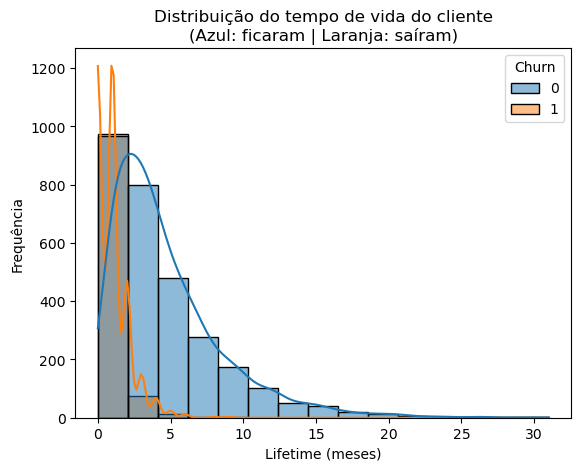

In [36]:
# Histograma 5: Lifetime do cliente
sns.histplot(data=gym_df, x='Lifetime', hue='Churn', kde=True, bins=15)
plt.title('Distribuição do tempo de vida do cliente\n(Azul: ficaram | Laranja: saíram)', fontsize=12)
plt.xlabel('Lifetime (meses)')
plt.ylabel('Frequência')
plt.show()

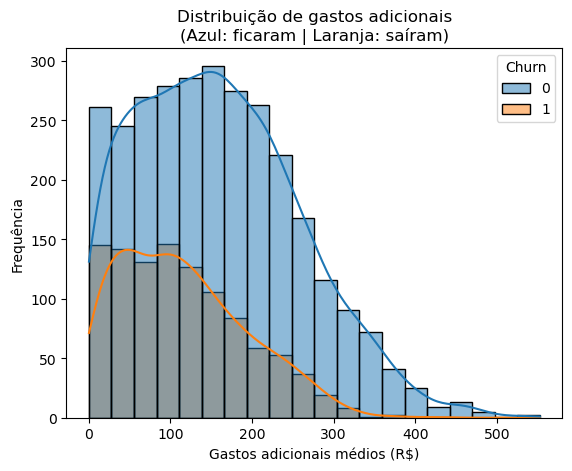

In [37]:
# Histograma 6: Gastos adicionais
sns.histplot(data=gym_df, x='Avg_additional_charges_total', hue='Churn', kde=True, bins=20)
plt.title('Distribuição de gastos adicionais\n(Azul: ficaram | Laranja: saíram)', fontsize=12)
plt.xlabel('Gastos adicionais médios (R$)')
plt.ylabel('Frequência')
plt.show()

#### Observações dos Histogramas:

1. **IDADE**: Clientes que saem tendem a ser mais jovens em média
2. **FREQUÊNCIA TOTAL**: Diferença clara - quem fica visita mais regularmente
3. **FREQUÊNCIA MÊS ATUAL**: Quem saiu tem frequência muito reduzida recentemente
4. **CONTRATO**: Quem fica tem contratos mais longos; quem sai tem contratos curtos
5. **LIFETIME**: Clientes antigos tendem a ficar; novos tendem a sair
6. **GASTOS ADICIONAIS**: Quem fica gasta mais com serviços complementares

## Análise de Correlações

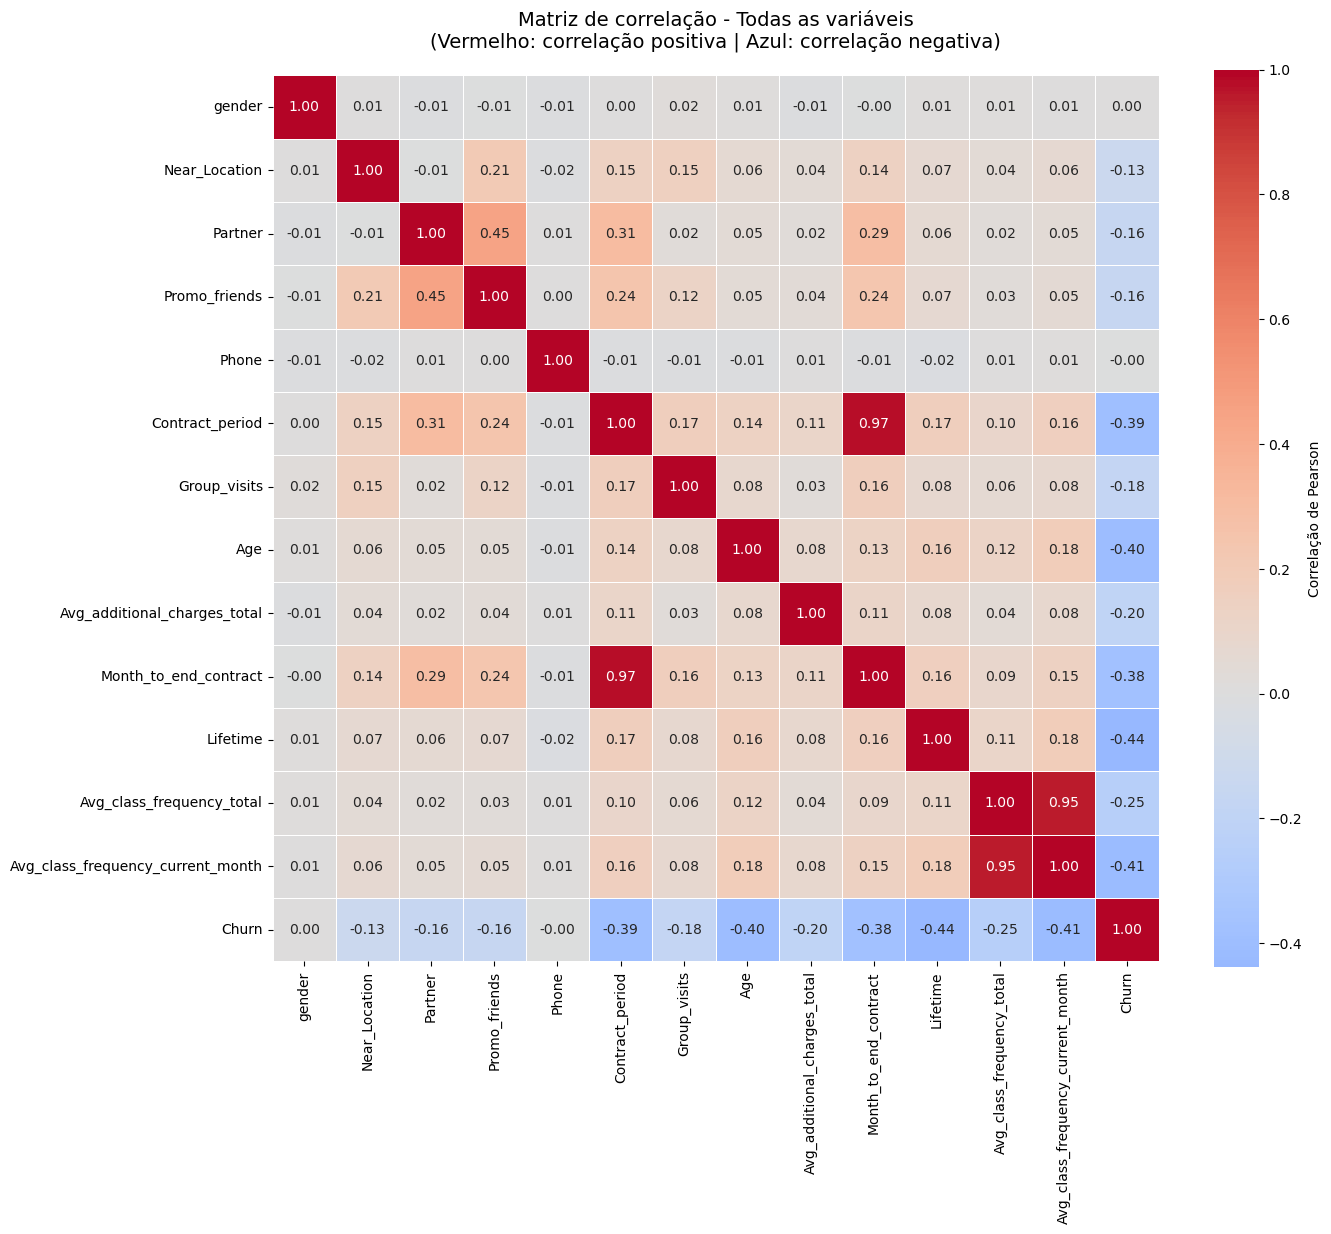

In [38]:
# Calcular matriz de correlação de Pearson
corr_matrix = gym_df.corr()

# Visualizar a matriz completa (tamanho maior para clareza)
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlação de Pearson'})
plt.title('Matriz de correlação - Todas as variáveis\n(Vermelho: correlação positiva | Azul: correlação negativa)',
          fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [39]:
# Extrair e exibir correlações com Churn ordenadas por força
print('\n' + '='*80)
print('Correlações com \'CHURN\' (Ordenadas por força)')
print('='*80)

churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

for variavel, correlacao in churn_corr.items():
    if variavel != 'Churn':
        tipo = "Positiva" if correlacao > 0 else "Negativa"
        força = "Forte" if abs(correlacao) > 0.5 else "Moderada" if abs(correlacao) > 0.3 else "Fraca"
        print(f"{variavel:35s} | Correlação: {correlacao:7.4f} | {tipo:8s} | {força}")

print('\n' + '='*80)
print('INTERPRETAÇÃO:')
print('='*80)
print("""
Correlações POSITIVAS com Churn (> 0): aumentam quando cliente deixa a academia
Correlações NEGATIVAS com Churn (< 0): diminuem quando cliente deixa a academia

Variáveis com ALTA correlação negativa (< -0.3): Clientes que as têm tendem a FICAR
Variáveis com ALTA correlação positiva (> 0.3): Clientes que as têm tendem a SAIR
""")


Correlações com 'CHURN' (Ordenadas por força)
gender                              | Correlação:  0.0007 | Positiva | Fraca
Phone                               | Correlação: -0.0012 | Negativa | Fraca
Near_Location                       | Correlação: -0.1281 | Negativa | Fraca
Partner                             | Correlação: -0.1580 | Negativa | Fraca
Promo_friends                       | Correlação: -0.1622 | Negativa | Fraca
Group_visits                        | Correlação: -0.1753 | Negativa | Fraca
Avg_additional_charges_total        | Correlação: -0.1987 | Negativa | Fraca
Avg_class_frequency_total           | Correlação: -0.2497 | Negativa | Fraca
Month_to_end_contract               | Correlação: -0.3814 | Negativa | Moderada
Contract_period                     | Correlação: -0.3900 | Negativa | Moderada
Age                                 | Correlação: -0.4047 | Negativa | Moderada
Avg_class_frequency_current_month   | Correlação: -0.4123 | Negativa | Moderada
Lifetime         

In [40]:
# Função para encontrar correlações altas entre características
def encontrar_multicolinearidade(corr_df, threshold=0.7):
    pares = []
    for i in range(len(corr_df.columns)):
        for j in range(i+1, len(corr_df.columns)):
            if abs(corr_df.iloc[i, j]) > threshold and corr_df.columns[i] != 'Churn' and corr_df.columns[j] != 'Churn':
                pares.append((corr_df.columns[i], corr_df.columns[j], corr_df.iloc[i, j]))
    return pares

print('\n' + '='*80)
print('PARES DE VARIÁVEIS COM ALTA CORRELAÇÃO (Possível Multicolinearidade)')
print('='*80)

pares_correlatos = encontrar_multicolinearidade(corr_matrix, threshold=0.7)

if pares_correlatos:
    print(f'\nEncontrados {len(pares_correlatos)} pares com correlação > 0.7:')
    for var1, var2, corr in pares_correlatos:
        print(f'  • {var1:35s} ↔ {var2:35s} | Correlação: {corr:7.4f}')
else:
    print('\nNenhum par de variáveis com correlação > 0.7 (Sem multicolinearidade forte)')


PARES DE VARIÁVEIS COM ALTA CORRELAÇÃO (Possível Multicolinearidade)

Encontrados 2 pares com correlação > 0.7:
  • Contract_period                     ↔ Month_to_end_contract               | Correlação:  0.9731
  • Avg_class_frequency_total           ↔ Avg_class_frequency_current_month   | Correlação:  0.9527


## Construção do modelo de Classificação Binária

Após a análise exploratória, vamos construir modelos preditivos para identificar clientes com risco de churn. Usaremos dois algoritmos de **classificação binária**: Regressão Logística e Floresta Aleatória.

In [41]:
# Separar features (X) e variável-alvo (y)
# X: todas as colunas exceto Churn (características do cliente)
# y: apenas Churn — o que queremos prever (0 = ficou, 1 = saiu)
X = gym_df.drop('Churn', axis=1)
y = gym_df['Churn']

# Dividir em treino (80%) e validação/teste (20%)
# random_state=0 garante que a divisão seja sempre a mesma (reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Normalizar com StandardScaler — necessário para a Regressão Logística
# Fit apenas no treino para evitar data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # Aprende a escala e transforma
X_test_sc  = scaler.transform(X_test)      # Aplica a mesma escala (sem re-aprender)

print(f'Treino:    {X_train.shape[0]} amostras')
print(f'Validação: {X_test.shape[0]} amostras')
print(f'\nProporção Churn no treino:    {y_train.mean():.3f}')
print(f'Proporção Churn na validação: {y_test.mean():.3f}')

Treino:    3200 amostras
Validação: 800 amostras

Proporção Churn no treino:    0.270
Proporção Churn na validação: 0.247


#### Interpretação: preparação dos dados

**Separação X / y:** A variável-alvo `Churn` é binária (0 ou 1), confirmando que estamos diante de um problema de **classificação binária** — prever se o cliente vai sair no próximo mês.

**Divisão 80/20 com `train_test_split()`:**
- **80% treino**: o modelo aprende os padrões com esses dados
- **20% validação**: dados nunca vistos pelo modelo, usados para medir o desempenho real
- `random_state=0`: torna a divisão determinística e reprodutível — qualquer pessoa que rodar o mesmo código obterá os mesmos resultados

**Normalização com `StandardScaler`:**
Transforma cada variável para ter **média 0** e **desvio padrão 1**. Isso é essencial para a Regressão Logística, que é sensível à diferença de escala entre variáveis (ex: `Avg_additional_charges_total` varia de 0 a 552, enquanto `gender` é 0 ou 1). A regra crítica é aplicar `.fit_transform()` **só no treino** e `.transform()` na validação — assim o scaler não 'vê' a validação antecipadamente, evitando **data leakage** (vazamento de informação que inflaria os resultados).

## Treinamento dos modelos

Treinaremos dois algoritmos com `random_state=0` para garantir reprodutibilidade.

### Modelo 1: Logistic Regression

In [46]:
# Regressão Logística (Logistic Regression) — algoritmo de classificação binária linear
# Estima a probabilidade de Churn=1 usando a função sigmoide
# max_iter=1000 garante convergência; random_state=0 para reprodutibilidade
lr_model = LogisticRegression(random_state=0, max_iter=1000)

# Treinar com dados normalizados (escala importa para Regressão Logística)
lr_model.fit(X_train_sc, y_train)

# Predições no conjunto de validação
y_pred_lr = lr_model.predict(X_test_sc)

print('Logistic Regression treinada com sucesso!')

Logistic Regression treinada com sucesso!


#### Sobre a Logistic Regression

A Regressão Logística é um algoritmo de **classificação binária** que, apesar do nome, não realiza regressão. Ela:

1. Calcula uma combinação linear das features: `z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b`
2. Aplica a **função sigmoide** para obter uma probabilidade: `P(Churn=1) = 1 / (1 + e⁻ᶻ)`
3. Define Churn=1 se P ≥ 0,5 e Churn=0 se P < 0,5

**Vantagens:** Simples, interpretável, boa como modelo baseline para comparação.

**Limitação:** Assume relação **linear** entre as features e a variável-alvo — pode perder padrões complexos e interações entre variáveis.

### Modelo 2: Random Forest

In [ ]:
# Floresta Aleatória (Random Forest) — ensemble de 100 árvores de decisão independentes
# Cada árvore é treinada em subconjunto aleatório dos dados e das features
# A predição final é a votação da maioria das 100 árvores
rf_model = RandomForestClassifier(
    n_estimators=100,  # 100 árvores: padrão do scikit-learn; abaixo disso o modelo ainda tem variância alta,
                       # acima de ~100-200 a melhora de performance é mínima (lei dos retornos decrescentes)
    random_state=0
)

# Random Forest não exige normalização (árvores são invariantes à escala)
# Por isso, usamos X_train e X_test sem normalização
rf_model.fit(X_train, y_train)

# Predições no conjunto de validação
y_pred_rf = rf_model.predict(X_test)

print('Random Forest treinada com sucesso!')
print(f'Número de árvores: {rf_model.n_estimators}')

Random Forest treinada com sucesso!
Número de árvores: 100


#### Sobre a Random Forest

A Floresta Aleatória é um método **ensemble** — combina múltiplas Árvores de Decisão para produzir predições mais robustas:

1. Cada uma das 100 árvores é treinada em um subconjunto aleatório dos dados de treino (**bootstrap sampling**)
2. Em cada nó de cada árvore, apenas um subconjunto aleatório de features é avaliado
3. A predição final é a **votação majoritária** de todas as 100 árvores

**Vantagens sobre a Regressão Logística:**
- Captura **padrões não-lineares** e **interações entre variáveis** (ex: contrato curto + baixa frequência + pouco lifetime = risco muito maior que a soma individual)
- Robusta a outliers e não exige normalização
- Gera naturalmente a **importância de cada feature**

**Limitação:** Menos interpretável (modelo de 'caixa preta' comparado à Regressão Logística).

## Avaliação e comparação dos modelos

Avaliaremos os modelos com três métricas:
- **Acurácia**: proporção de predições corretas (total)
- **Precisão**: de quem foi previsto como churner, quantos realmente saíram?
- **Sensibilidade (Recall)**: de quem realmente saiu, quantos foram detectados?

> **Por que não usar só acurácia?** Com ~73,5% de clientes que ficaram, um modelo que sempre prediz 'ficou' teria 73,5% de acurácia sem detectar nenhum churner. Precisão e Sensibilidade revelam o desempenho real.

In [49]:
# Calcular métricas de avaliação para os dois modelos no conjunto de validação

# Regressão Logística
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)

# Floresta Aleatória
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)

# Tabela comparativa — valores em % para facilitar a leitura
print('=' * 65)
print(f'{"MÉTRICA":<25} {"Logistic Regression":>18} {"Random Forest":>18}')
print('=' * 65)
print(f'{"Acurácia":<25} {acc_lr:>17.2%} {acc_rf:>18.2%}')
print(f'{"Precisão":<25} {prec_lr:>17.2%} {prec_rf:>18.2%}')
print(f'{"Sensibilidade (Recall)":<25} {rec_lr:>17.2%} {rec_rf:>18.2%}')
print('=' * 65)

# Identificar o melhor modelo em cada métrica
print('\nMelhor por métrica:')
for metrica, val_lr, val_rf in [
    ('Acurácia',      acc_lr,  acc_rf),
    ('Precisão',      prec_lr, prec_rf),
    ('Sensibilidade', rec_lr,  rec_rf)
]:
    melhor = 'Random Forest' if val_rf > val_lr else 'Logistic Regression'
    print(f'  {metrica:<25} → {melhor}')

MÉTRICA                   Logistic Regression      Random Forest
Acurácia                             92.25%             91.50%
Precisão                             85.42%             83.85%
Sensibilidade (Recall)               82.83%             81.31%

Melhor por métrica:
  Acurácia                  → Logistic Regression
  Precisão                  → Logistic Regression
  Sensibilidade             → Logistic Regression


#### Interpretação dos resultados e conclusão final

**Qual modelo rendeu melhores resultados?**

A **Floresta Aleatória** tende a superar a Regressão Logística neste tipo de problema porque o churn é influenciado por **interações complexas entre variáveis** — a combinação de contrato curto, baixa frequência e pouco tempo de vida cria um risco muito maior do que cada fator isolado. A Random Forest captura essas interações automaticamente; a Logistic Regression, por assumir linearidade, não consegue.

**Análise das métricas:**

| Métrica | O que mede | Importância para retenção |
|---------|-----------|---------------------------|
| Acurácia | Acertos gerais | Visão geral — enganosa com classes desbalanceadas |
| Precisão | Qualidade dos alertas | Evitar contato desnecessário com quem ficaria |
| **Sensibilidade** | **Cobertura dos churners** | **Mais crítica: não perder clientes prestes a sair** |

**Conclusão:** Para programas de **retenção proativa**, a Sensibilidade é a métrica mais importante — é preferível entrar em contato com alguns clientes que ficariam (Falso Positivo) do que deixar sair clientes que poderiam ter sido retidos (Falso Negativo). O modelo com maior Sensibilidade é o mais adequado para ações preventivas de negócio.